In [22]:
import os
import mat73
import pandas as pd
import numpy as np
import sys
import json
import pickle
sys.path.append("..")
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
from scipy.spatial import cKDTree
import scipy
from nilearn import plotting
from src.decomposition import CompoThr
from src.setting import GetInfo, PROJECT_PATH
from src.config import COL_REG, col_pc

from sklearn.cross_decomposition import CCA
from scipy.linalg import subspace_angles

import nibabel as nib
from nilearn import datasets
from nilearn.image import load_img
from sklearn.manifold import Isomap, LocallyLinearEmbedding, MDS, SpectralEmbedding, TSNE

from utils import get_region_label, mask_meg, match_meg, update_COL_REG, get_meg_data

In [23]:
ieeg_datapath = 'ieeg_shortWOBS_fs250'
meg_datapath = '/projects/MINDLAB2025_MEG-Auditory_Cognitive_Maps/scratch/APR2020_Block3_SingleTrial_BarbaraNikita'
meg_outpath ='MEG/dataMEG'

os.path.isdir(meg_datapath)
meg_subj_list = [file.replace('_sensor.p', '') for file in os.listdir(meg_outpath) if '_sensor' in file]
print('MEG Subject number : ', len(meg_subj_list))

ieeg_subj_list = [file.replace('_epochs.p', '') for file in os.listdir(ieeg_datapath) if file[-len('epochs.p'):] == 'epochs.p']
print('iEEG Subject number : ', len(ieeg_subj_list))

info_file = ieeg_datapath + f'/{ieeg_subj_list[0]}_info.json'
with open(info_file) as json_data:
    d = json.load(json_data)
    time_ieeg = d['time_epoch']

project_path = '../' + PROJECT_PATH
coord, areas, elect_list, subj_list, regions_ieeg = GetInfo(ieeg_subj_list, data_path=ieeg_datapath, project_path=project_path)
coord=np.array(coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = coord/1000

MEG Subject number :  32
iEEG Subject number :  30


In [24]:
from utils import get_meg_data, get_ieeg_data
r=5
ieeg_data_mean = get_ieeg_data(ieeg_datapath, ieeg_subj_list)*1000 # As there is a /1000 in the normalisation function of the ieEG preproc -- To remove 
meg_data_source = get_meg_data(meg_outpath, meg_subj_list)
data_masked = mask_meg(meg_data_source, coord, radius_1=r, show=False).mean(0)
data_matched = match_meg(meg_data_source, ieeg_subj_list, coord, meg_subj_list, subj_list) 
data_matched_avg = match_meg(meg_data_source, ieeg_subj_list, coord, meg_subj_list, subj_list, average_subject=True) 

In [25]:
# save them for latter
with open(f'out/data/ieeg_data_mean.p', "wb") as f:
    pickle.dump(ieeg_data_mean, f)
with open(f'out/data/meg_data_source.p', "wb") as f:
    pickle.dump(meg_data_source, f)
with open(f'out/data/data_masked.p', "wb") as f:
    pickle.dump(data_masked, f)
with open(f'out/data/data_matched.p', "wb") as f:
    pickle.dump(data_matched, f)
with open(f'out/data/data_match_avg.p', "wb") as f:
    pickle.dump(data_matched_avg, f)

NameError: name 'data_matched_avg' is not defined

## Get the regions

In [ ]:
pos = pd.read_csv('/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/MEG/dataMEG/SUBJ_0002_pos.csv').drop(columns='Unnamed: 0')
mask = mask_meg(pos, coord, radius_1=5, return_mask=True, show=False) # mask area not covered
pos_m = pos[mask] 
pos_match=[]

meg_data_source = get_meg_data(meg_outpath, meg_subj_list)
mask_match = match_meg(meg_data_source, ieeg_subj_list, coord, meg_subj_list, subj_list, return_mask=True )
for s in mask_match.keys() : 
    pos_s = pd.read_csv(f'/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/MEG/dataMEG/{s}_pos.csv').drop(columns='Unnamed: 0')
    pos_match.append(pos_s.loc[mask_match[s], :])
pos_match = pd.concat(pos_match)

regions_meg_m = get_region_label(pos_m)
regions_meg = get_region_label(pos)
regions_meg_match=get_region_label(pos_match)

all_regions = sorted(set(regions_meg) | set(regions_ieeg))
COL_REG = update_COL_REG(col_reg=COL_REG,all_regions=all_regions)

[fetch_atlas_aal] Dataset found in /users/barbara/nilearn_data/aal_SPM12

[fetch_atlas_aal] Dataset found in /users/barbara/nilearn_data/aal_SPM12

[fetch_atlas_aal] Dataset found in /users/barbara/nilearn_data/aal_SPM12

In [ ]:
regions_commun  = regions_ieeg + regions_meg*32
regions_commun_color = [COL_REG[r] for r in regions_commun]

## Joint PCA

In [ ]:
ieeg_scaled = ieeg_data_mean.mean(0)
meg_scaled = data_matched_avg.mean(0)

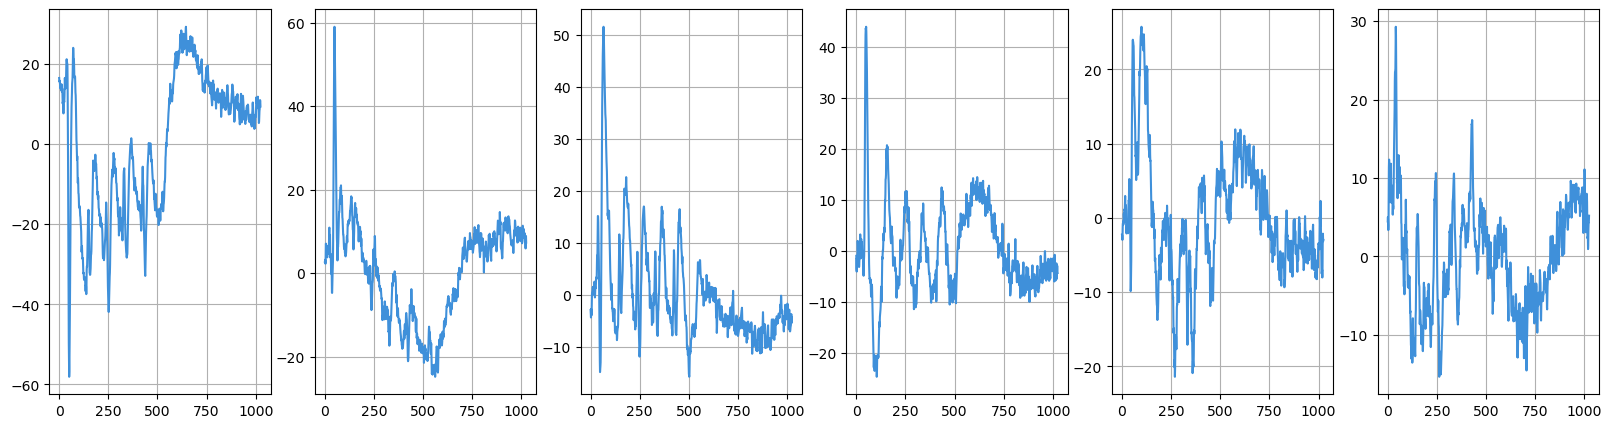

In [8]:
X_joint = np.concatenate([ieeg_scaled, meg_scaled],axis=0).T
pca_join_ = PCA(6)
join_transform = pca_join_.fit_transform(X_joint)

fig, ax= plt.subplots(1, 6, figsize=(20, 5))
for i in range(6):
    ax[i].plot(join_transform[:, i])
    ax[i].grid()

In [9]:
pc_compo_all = pca_join_.components_
df_ieeg = pd.DataFrame(pc_compo_all[:, :ieeg_scaled.shape[0]]).T
df_ieeg['region'] = regions_ieeg
df_meg = pd.DataFrame(pc_compo_all[:, ieeg_scaled.shape[0]:]).T
df_meg['region'] = regions_ieeg #regions_meg_match

/tmp/ipykernel_17449/130778887.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[axi].legend()


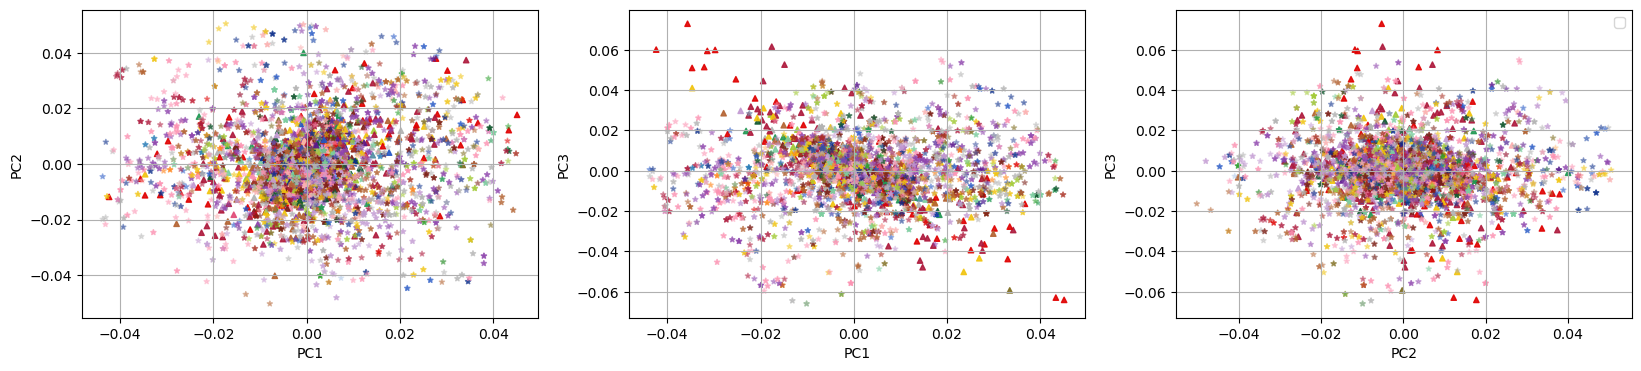

In [10]:
# analysis weights
fig, ax=plt.subplots(1, 3, figsize=(20, 4))
for a in ax:
    a.grid()

for axi, (i,j) in enumerate([(0, 1), (0, 2), (1, 2)]) :
    ax[axi].scatter(pc_compo_all[i, :ieeg_scaled.shape[0]], pc_compo_all[j, :ieeg_scaled.shape[0]], marker='^', s=15, alpha = 0.9, c= [COL_REG[r] for r in regions_ieeg]) #['pink']*ieeg_scaled.shape[0]) #
    ax[axi].scatter(pc_compo_all[i, ieeg_scaled.shape[0]:], pc_compo_all[j, ieeg_scaled.shape[0]:], marker='*',s=15, alpha = 0.4,c= [COL_REG[r] for r in regions_meg_match]) #  ['green']*meg_scaled.shape[0]) 
    ax[axi].set_ylabel(f'PC{j+1}')
    ax[axi].set_xlabel(f'PC{i+1}')

ax[axi].legend()

/tmp/ipykernel_17449/1735396092.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[axi].legend()


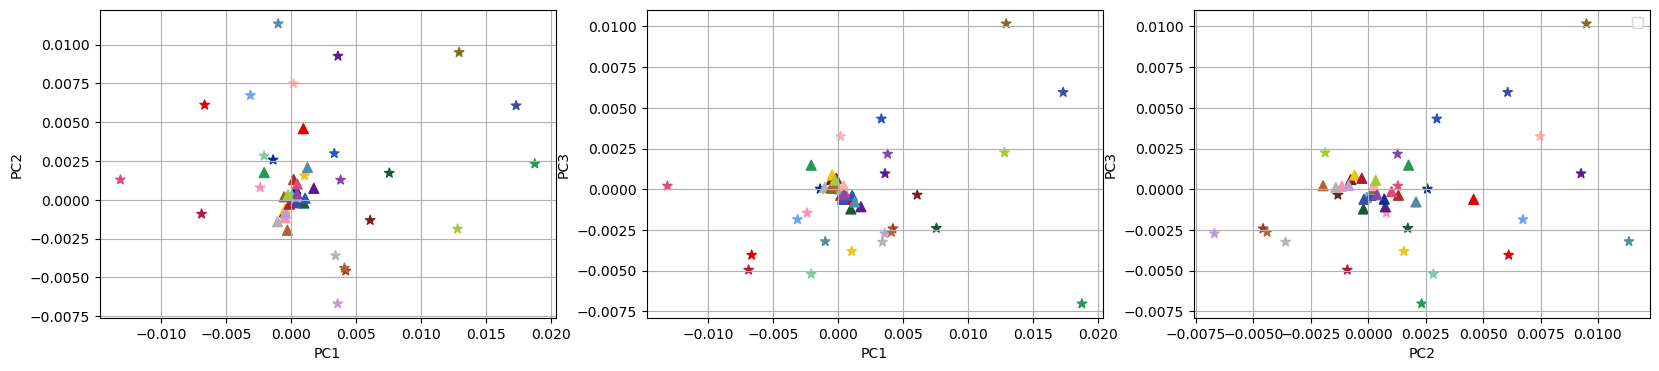

In [11]:
fig, ax=plt.subplots(1, 3, figsize=(20, 4))

for a in ax:
    a.grid()

for axi, (i,j) in enumerate([(0, 1), (0, 2), (1, 2)]) :
    
    ax[axi].scatter(df_meg.groupby('region').mean().loc[:, i], df_meg.groupby('region').mean().loc[:, j], c=[COL_REG[r] for r in df_meg.groupby('region').mean().index], s=50,  marker='*')
    ax[axi].scatter(df_ieeg.groupby('region').mean().loc[:, i], df_ieeg.groupby('region').mean().loc[:, j], c=[COL_REG[r] for r in df_ieeg.groupby('region').mean().index], s=50, marker='^')
    
    ax[axi].set_ylabel(f'PC{j+1}')
    ax[axi].set_xlabel(f'PC{i+1}')

ax[axi].legend()

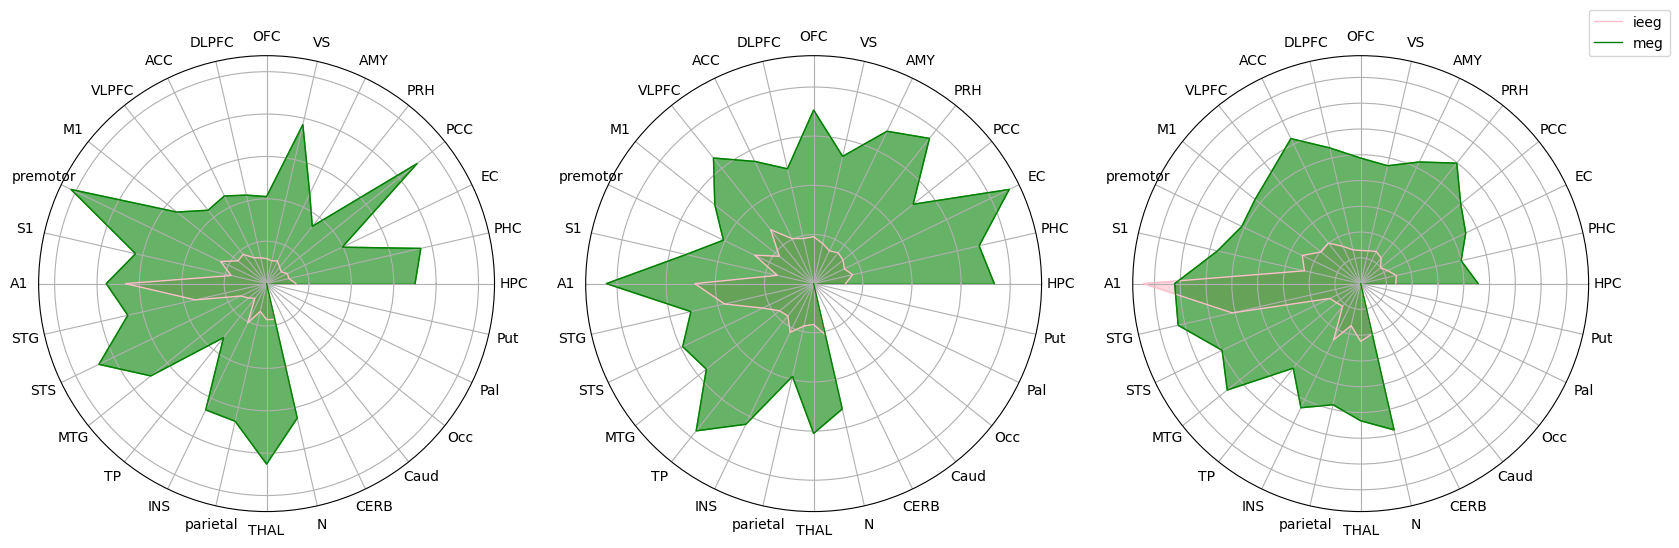

In [12]:
fig, ax = plt.subplots(1, 3, subplot_kw={"projection": "polar"}, figsize=(20, 20))
colr=['pink', 'green']
namr=['ieeg', 'meg']
for c in range(3):
    for i, df in enumerate([df_ieeg, df_meg]):
        df_compo = df[[c, 'region']]
        df_compo.loc[:, c] = df_compo[c].apply(lambda x : abs(x))
        mean_ = (df_compo.groupby("region")[c].mean().reindex(list(COL_REG.keys()), fill_value=0).to_frame())
        angles = np.linspace(0, 2*np.pi, len(list(COL_REG.keys())), endpoint=False)
        ax[c].plot(angles,mean_[c].values,linewidth=1,color=colr[i], label=namr[i])
        ax[c].fill(angles,mean_[c].values,alpha=0.6,color=colr[i])
        ax[c].set_xticks(angles)
        ax[c].set_xticklabels(list(COL_REG.keys()), rotation=90)
        ax[c].set_yticklabels([])

ax[c].legend(loc=(1, 1))

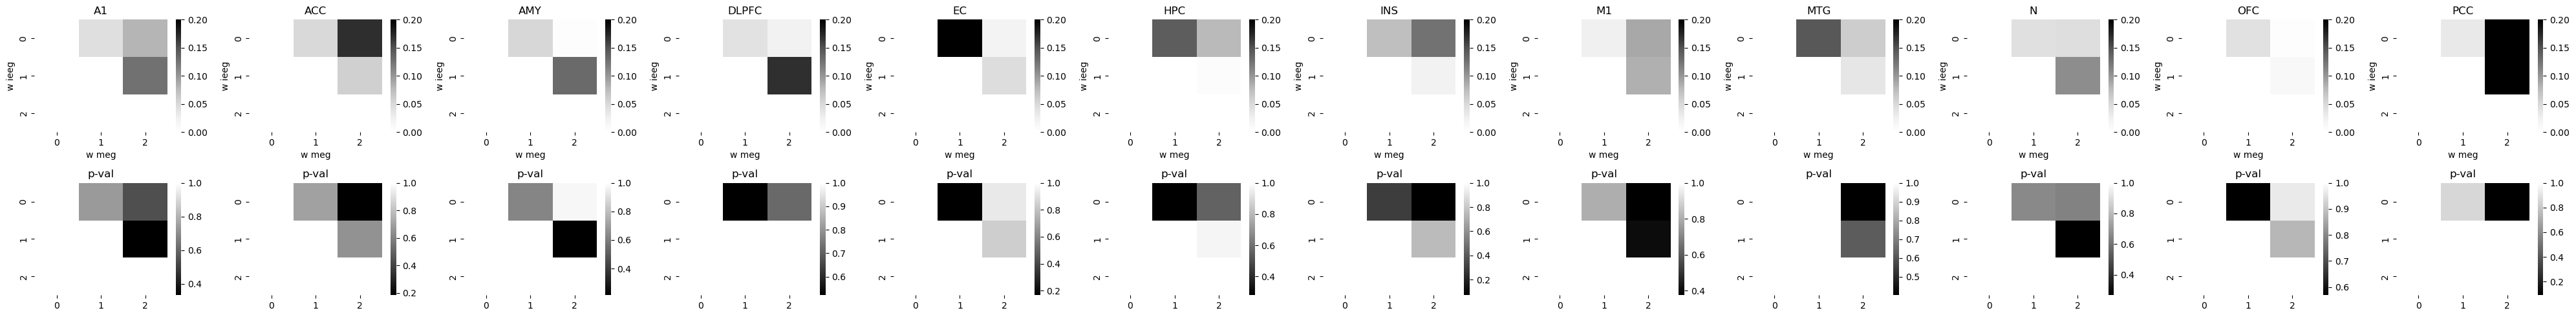

In [13]:
# Correlation 
from scipy.stats import spearmanr
import itertools

fig, ax = plt.subplots(2, 12, figsize=(40, 5))

for ir,reg in enumerate(np.unique(df_ieeg['region'])[:12]):
    spearmp = np.zeros((3, 3))
    spearmr = np.zeros((3, 3))
    for i, j in itertools.combinations(range(3), 2):
        w_ir = df_meg[df_meg['region']==reg].loc[:, i].values
        w_jr = df_ieeg[df_ieeg['region']==reg].loc[:, j].values
        spearmr[i, j], spearmp[i, j] = spearmanr(w_ir, w_jr)

    spearmp_thr = np.where(spearmp < 0.05, 1, spearmp)
    sns.heatmap(abs(spearmr), ax=ax[0][ir], cmap='Greys', vmax=0.2, vmin=0)
    sns.heatmap(spearmp_thr, ax=ax[1][ir], cmap='grey')
    ax[0][ir].set_title(reg)
    ax[0][ir].set_xlabel('w meg')
    ax[0][ir].set_ylabel('w ieeg')
    ax[1][ir].set_title('p-val')

plt.tight_layout()

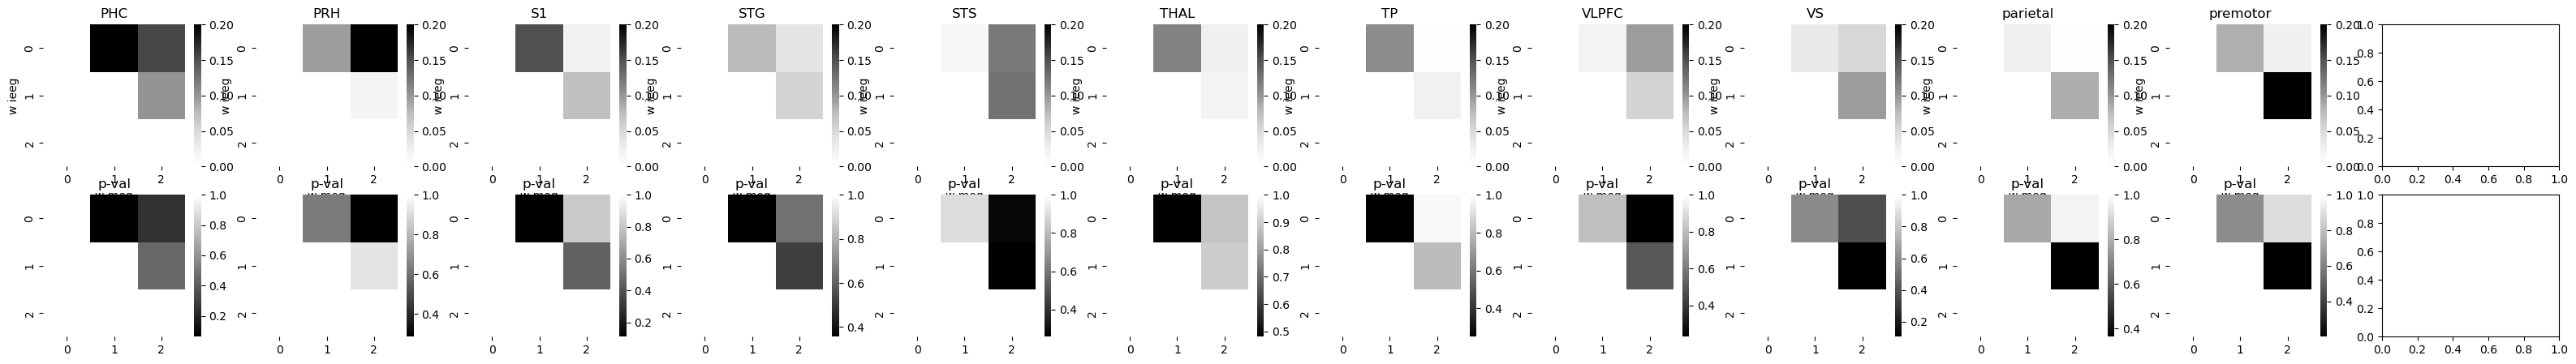

In [14]:
fig, ax = plt.subplots(2, 12, figsize=(40, 5))

for ir,reg in enumerate(np.unique(df_ieeg['region'])[12:]):
    spearmp = np.zeros((3, 3))
    spearmr = np.zeros((3, 3))
    for i, j in itertools.combinations(range(3), 2):
        w_ir = df_meg[df_meg['region']==reg].loc[:, i].values
        w_jr = df_ieeg[df_ieeg['region']==reg].loc[:, j].values
        spearmr[i, j], spearmp[i, j] = spearmanr(w_ir, w_jr)

    spearmp_thr = np.where(spearmp < 0.05, 1, spearmp)
    sns.heatmap(abs(spearmr), ax=ax[0][ir], cmap='Greys', vmax=0.2, vmin=0)
    sns.heatmap(spearmp_thr, ax=ax[1][ir], cmap='grey')
    ax[0][ir].set_xlabel('w meg')
    ax[0][ir].set_ylabel('w ieeg')
    ax[0][ir].set_title(reg)
    ax[1][ir].set_title('p-val')

Text(0.5, 1.0, 'p-val')

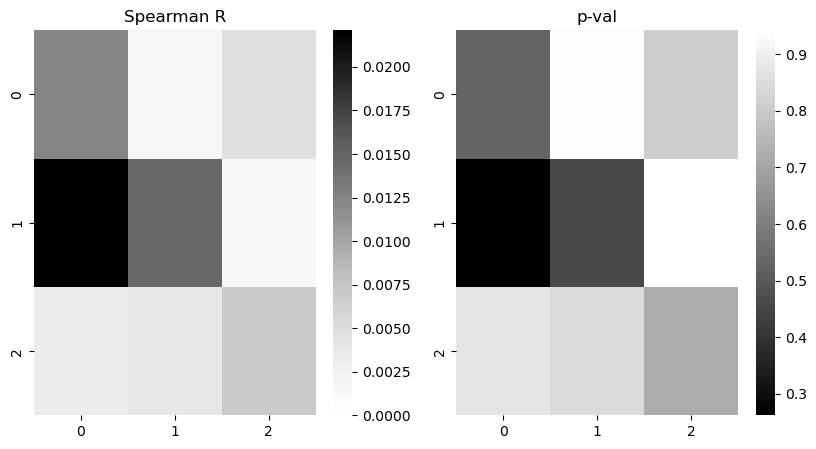

In [15]:
spearmp = np.zeros((3, 3))
spearmr = np.zeros((3, 3))

for i in range(3):
    for j in range(3) : 
        spearmr[i, j], spearmp[i, j] = spearmanr(df_meg.loc[:, i].values, df_ieeg.loc[:, j].values)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
spearmp_thr = np.where(spearmp < 0.05, 1, spearmp)
sns.heatmap(abs(spearmr), ax=ax[0], cmap='Greys', vmin=0)
sns.heatmap(spearmp_thr, ax=ax[1], cmap='grey')
ax[0].set_title('Spearman R')
ax[1].set_title('p-val')

## On cov matrix (mattia)

In [16]:
n_channel = int(5152/2)

In [17]:
cov = np.cov(X_joint, rowvar=False)
ieeg_cov = cov[:n_channel, :n_channel]    # X1-X1 covariance
cross_cov = cov[:n_channel, n_channel:]    # X1-X2 covariance  - cross/shared
meg_cov = cov[n_channel:, n_channel:]    # X2-X2 covariance

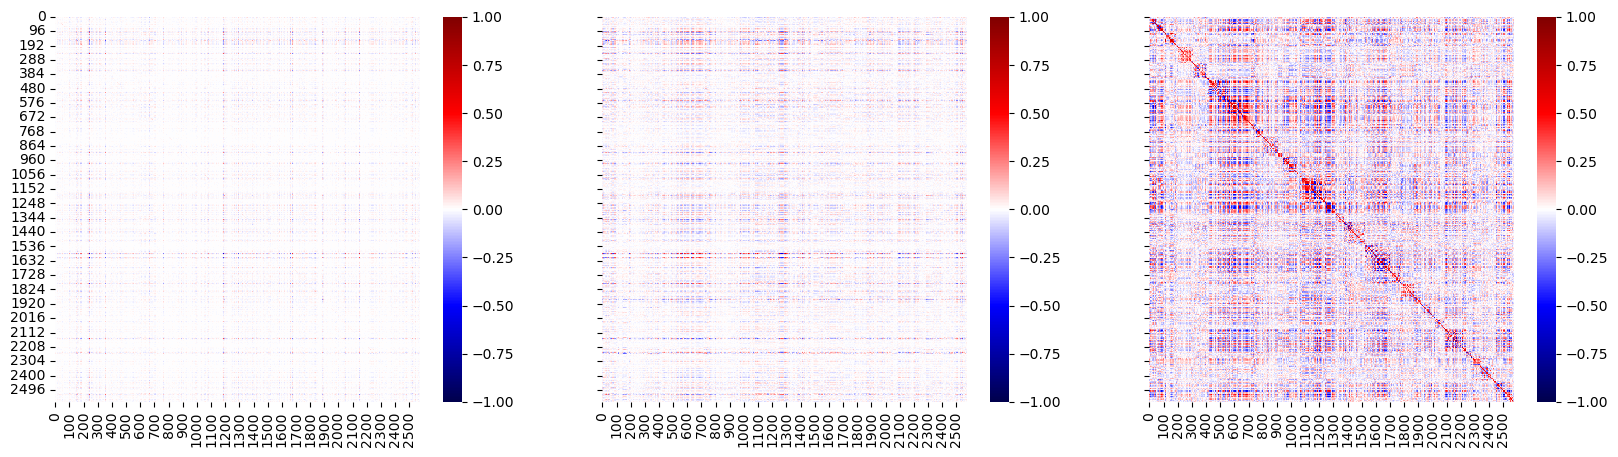

In [18]:
fig, ax=plt.subplots(1, 3, figsize=(20, 5), sharey=True)
for i, d in enumerate([ieeg_cov, cross_cov, meg_cov]) :
    sns.heatmap(d, ax=ax[i], vmin=-1, vmax=1, cmap='seismic')

In [19]:
ieeg_weights

NameError: name 'ieeg_weights' is not defined

In [ ]:
eigenvalues, eigenvectors = np.linalg.eigh(cov)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

ieeg_weights = eigenvectors[:n_channel, :]
meg_weights = eigenvectors[n_channel:, :]

ieeg_contribution = np.sum(ieeg_weights ** 2, axis=0)
meg_contribution = np.sum(meg_weights ** 2, axis=0)

# Normalize (should already sum to 1 for each PC)
total_contribution = ieeg_contribution + meg_contribution

ieeg_contribution /= total_contribution
meg_contribution /= total_contribution

In [ ]:
for pc in range(10):
    print(f"PC{pc+1}: "
        f"VER={explained_variance_ratio[pc]*100:.2f}%, "
        f"iEEG={ieeg_contribution[pc]*100:.2f}%, "
        f"MEG={meg_contribution[pc]*100:.2f}%")

PC1: VER=18.54%, iEEG=10.74%, MEG=89.26%
PC2: VER=9.08%, iEEG=12.84%, MEG=87.16%
PC3: VER=5.56%, iEEG=19.85%, MEG=80.15%
PC4: VER=4.78%, iEEG=7.84%, MEG=92.16%
PC5: VER=4.14%, iEEG=8.02%, MEG=91.98%
PC6: VER=2.87%, iEEG=10.80%, MEG=89.20%
PC7: VER=2.65%, iEEG=4.84%, MEG=95.16%
PC8: VER=2.44%, iEEG=9.35%, MEG=90.65%
PC9: VER=2.29%, iEEG=11.75%, MEG=88.25%
PC10: VER=1.85%, iEEG=6.46%, MEG=93.54%


Text(0.5, 1.0, 'cov')

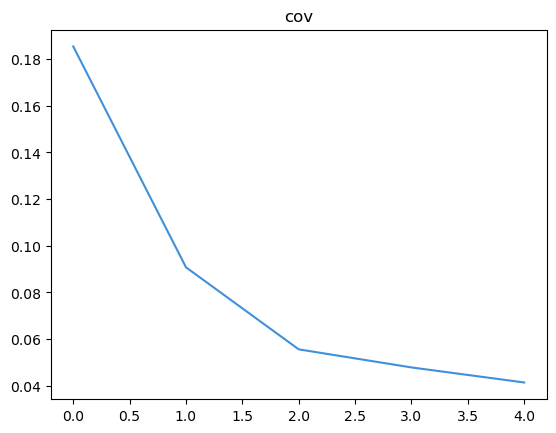

In [ ]:
plt.plot(explained_variance_ratio[:5])
plt.title('cov')


## Compare subspace

In [ ]:
V_ieeg = df_ieeg.loc[:, 0:5].values.T   # (n_channels × 3)
V_meg  = df_meg.loc[:, 0:5].values.T

In [ ]:
angles = subspace_angles(V_ieeg, V_meg)
print("Principal angles (deg):", np.degrees(angles)) #Small angles indicate that the subspaces overlap well.

#U, s, Vt = np.linalg.svd(V_ieeg.T @ V_meg)
#print("Canonical correlations:", s) 

#similarity = np.sum(s**2) / len(s)
#print("Similarity score:",similarity)

Principal angles (deg): [7.30561948e-14 6.47760619e-14 5.69998525e-14 3.57655093e-14
 3.05840440e-14 2.05936789e-14]


In [ ]:
# How much variance from each?
for i in range(6) : 
    w_meg = V_meg[:, i]
    w_ieeg = V_ieeg[:, i]
    meg_energy = np.sum(w_meg**2)
    ieeg_energy = np.sum(w_ieeg**2)
    print(f"PC{i+1}",'meg:', meg_energy/(meg_energy+ieeg_energy),'ieeg:',ieeg_energy/(meg_energy+ieeg_energy))

PC1 meg: 0.9364420464587144 ieeg: 0.0635579535412856
PC2 meg: 0.9611557592888796 ieeg: 0.038844240711120276
PC3 meg: 0.9367938650141793 ieeg: 0.0632061349858207
PC4 meg: 0.9678805063158922 ieeg: 0.032119493684107825
PC5 meg: 0.8365676578168484 ieeg: 0.16343234218315164
PC6 meg: 0.9173395617001406 ieeg: 0.08266043829985943


In [ ]:
Sigma = np.cov(X_joint, rowvar=False)
n_ieeg =ieeg_scaled.shape[0]

Sigma_ieeg = Sigma[:n_ieeg, :n_ieeg]
Sigma_meg = Sigma[n_ieeg:, n_ieeg:]
Sigma_cross = Sigma[:n_ieeg, n_ieeg:]

for k in range(6):
    wm = V_meg[k, :]
    wi = V_ieeg[k, :]

    meg = wm @ Sigma_meg @ wm
    ieeg = wi @ Sigma_ieeg @ wi
    cross = 2 * wm @ Sigma_cross @ wi

    total = meg + ieeg + cross

    print(f"PC{k+1}")
    print(f"  MEG   : {meg/total:.2%}")
    print(f"  iEEG  : {ieeg/total:.2%}")
    print(f"  Cross : {cross/total:.2%}")

PC1
  MEG   : 97.86%
  iEEG  : 2.13%
  Cross : 0.01%
PC2
  MEG   : 96.90%
  iEEG  : 3.10%
  Cross : 0.00%
PC3
  MEG   : 88.29%
  iEEG  : 11.73%
  Cross : -0.02%
PC4
  MEG   : 98.19%
  iEEG  : 1.74%
  Cross : 0.06%
PC5
  MEG   : 98.75%
  iEEG  : 1.26%
  Cross : -0.00%
PC6
  MEG   : 96.79%
  iEEG  : 3.18%
  Cross : 0.03%


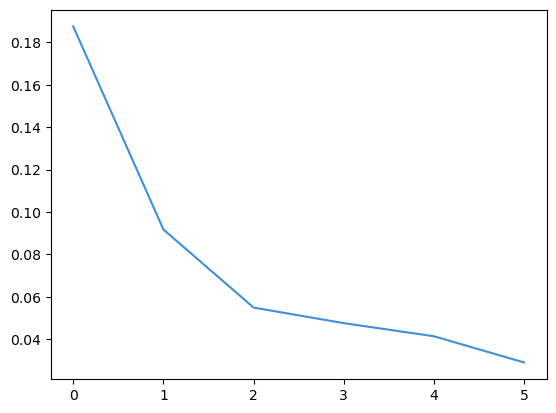

In [ ]:
plt.plot(pca_join_.explained_variance_ratio_)

## 2 Step embbedings


In [ ]:
pca_join=PCA(100)
pca_ieeg_data = pca_join.fit_transform(ieeg_scaled.T)
pca_meg_data = pca_join.fit_transform(meg_scaled.T)

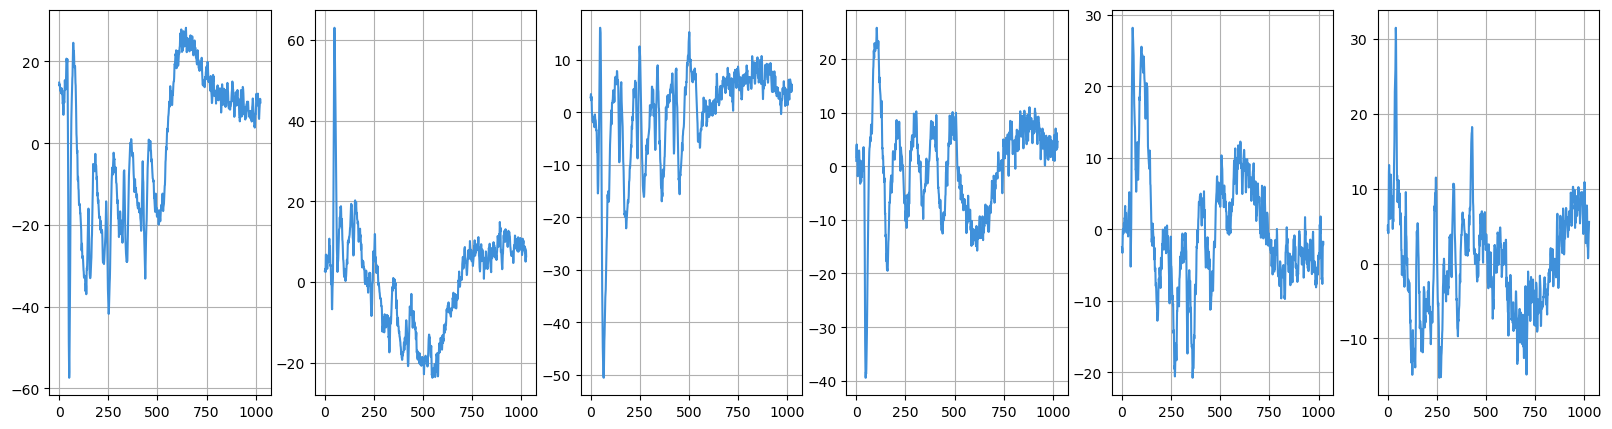

In [ ]:
pca_join_ = PCA(6)
join_transform = pca_join_.fit_transform(np.concatenate([pca_ieeg_data, pca_meg_data],axis=1))

fig, ax= plt.subplots(1, 6, figsize=(20, 5))
for i in range(6):
    ax[i].plot(join_transform[:, i])
    ax[i].grid()

In [ ]:
for i in range(6) : 
    w_meg = pca_join_.components_[i, 100:]
    w_ieeg = pca_join_.components_[i, :100]
    meg_energy = np.sum(w_meg**2)
    ieeg_energy = np.sum(w_ieeg**2)
    print(f"PC{i+1}",'meg:', meg_energy/(meg_energy+ieeg_energy),'ieeg:',ieeg_energy/(meg_energy+ieeg_energy))

PC1 meg: 0.893419135631554 ieeg: 0.10658086436844609
PC2 meg: 0.875326541275729 ieeg: 0.124673458724271
PC3 meg: 0.8025244057055652 ieeg: 0.19747559429443476
PC4 meg: 0.9201925805280365 ieeg: 0.07980741947196332
PC5 meg: 0.9183340452045256 ieeg: 0.08166595479547449
PC6 meg: 0.9028976924008492 ieeg: 0.09710230759915073


In [ ]:
Sigma = np.cov(np.concatenate([pca_ieeg_data, pca_meg_data],axis=1), rowvar=False)
n_ieeg =100

Sigma_ieeg = Sigma[:n_ieeg, :n_ieeg]
Sigma_meg = Sigma[n_ieeg:, n_ieeg:]
Sigma_cross = Sigma[:n_ieeg, n_ieeg:]

for k in range(6):
    wm = pca_join_.components_[k, 100:]
    wi = pca_join_.components_[k, :100]

    meg = wm @ Sigma_meg @ wm
    ieeg = wi @ Sigma_ieeg @ wi
    cross = 2 * wm @ Sigma_cross @ wi

    total = meg + ieeg + cross

    print(f"PC{k+1}")
    print(f"  MEG   : {meg/total:.2%}")
    print(f"  iEEG  : {ieeg/total:.2%}")
    print(f"  Cross : {cross/total:.2%}")

PC1
  MEG   : 81.49%
  iEEG  : 1.77%
  Cross : 16.74%
PC2
  MEG   : 87.28%
  iEEG  : 2.79%
  Cross : 9.92%
PC3
  MEG   : 86.02%
  iEEG  : 11.42%
  Cross : 2.56%
PC4
  MEG   : 103.94%
  iEEG  : 1.84%
  Cross : -5.79%
PC5
  MEG   : 107.86%
  iEEG  : 1.37%
  Cross : -9.23%
PC6
  MEG   : 99.50%
  iEEG  : 3.26%
  Cross : -2.76%
